# Week 12: Deep Learning for Time Series

Model real-world time series using:
- Train time series DL models (Simple LSTM)
- Make data stationary and train all models on stationary data
- Compare with statistical (ARIMA) and ML (XGBoost) time series models

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Statistical models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# ML models
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Data Preparation

In [32]:
# Load data
df = pd.read_parquet('basel-energy-demand.parquet')
print(f"Original shape: {df.shape}")
print(df.head())

Original shape: (482055, 12)
   timestamp_interval_start timestamp_interval_start_text  stromverbrauch_kwh  \
0 2025-09-30 21:45:00+00:00      2025-09-30T23:45:00+0200           27318.806   
1 2025-09-30 21:30:00+00:00      2025-09-30T23:30:00+0200           27922.965   
2 2025-09-30 21:15:00+00:00      2025-09-30T23:15:00+0200           28249.646   
3 2025-09-30 21:00:00+00:00      2025-09-30T23:00:00+0200           29038.658   
4 2025-09-30 20:45:00+00:00      2025-09-30T22:45:00+0200           30034.410   

   grundversorgte_kunden_kwh  freie_kunden_kwh  year  month  day  weekday  \
0                  12528.324         14790.482  2025      9   30        1   
1                  13122.010         14800.955  2025      9   30        1   
2                  13400.783         14848.863  2025      9   30        1   
3                  14031.674         15006.984  2025      9   30        1   
4                  14801.535         15232.875  2025      9   30        1   

   dayofyear  quarter

In [33]:
# Sort by timestamp (data is reverse-ordered)
df = df.sort_values('timestamp_interval_start').reset_index(drop=True)

# Set timestamp as index
df['timestamp'] = pd.to_datetime(df['timestamp_interval_start'])
df = df.set_index('timestamp')

# Extract target variable (energy consumption in MWh)
energy = df['stromverbrauch_kwh'] / 1000  # Convert kWh to MWh

# Resample to hourly for faster training
energy_hourly = energy.resample('H').mean()
energy_hourly = energy_hourly.dropna()

print(f"Hourly samples: {len(energy_hourly)}")
print(f"Date range: {energy_hourly.index[0]} to {energy_hourly.index[-1]}")
print(f"\nStatistics:")
print(f"  Mean: {energy_hourly.mean():.2f} MWh")
print(f"  Std:  {energy_hourly.std():.2f} MWh")

Hourly samples: 120514
Date range: 2011-12-31 23:00:00+00:00 to 2025-09-30 21:00:00+00:00

Statistics:
  Mean: 38.45 MWh
  Std:  9.03 MWh


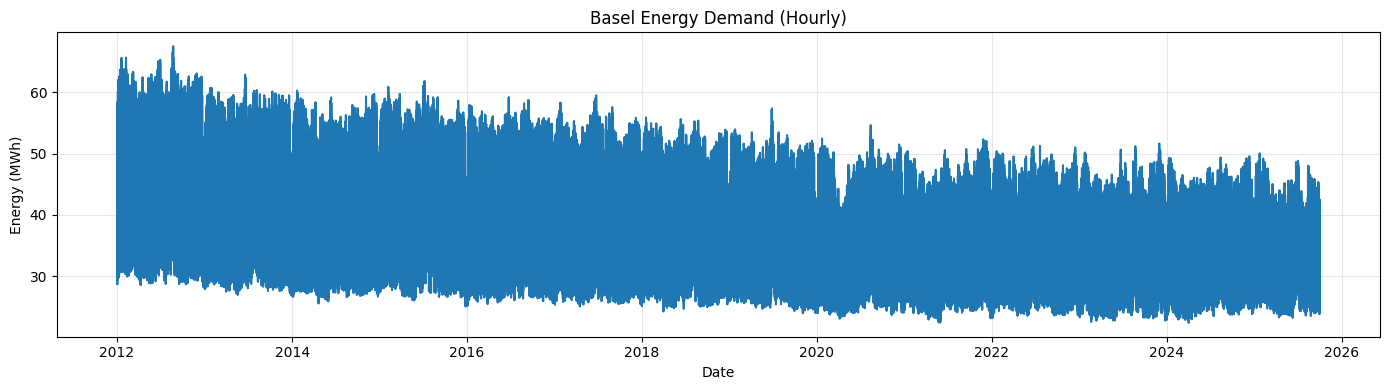

In [34]:
# Plot the time series
plt.figure(figsize=(14, 4))
plt.plot(energy_hourly.index, energy_hourly.values)
plt.title('Basel Energy Demand (Hourly)')
plt.xlabel('Date')
plt.ylabel('Energy (MWh)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Make Data Stationary

In [35]:
def check_stationarity(data, name="Data"):
    """Perform ADF test for stationarity."""
    result = adfuller(data)
    print(f"{name}:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.6f}")
    print(f"  Stationary: {'Yes' if result[1] < 0.05 else 'No'}")
    return result[1] < 0.05

print("Stationarity Tests:")
print("-" * 40)
check_stationarity(energy_hourly.values, "Original")

Stationarity Tests:
----------------------------------------
Original:
  ADF Statistic: -24.8804
  p-value: 0.000000
  Stationary: Yes


True

In [36]:
# Apply first-order differencing to ensure stationarity
energy_diff = energy_hourly.diff().dropna()

print("\nAfter differencing:")
check_stationarity(energy_diff.values, "Differenced")

print(f"\nDifferenced data statistics:")
print(f"  Mean: {energy_diff.mean():.4f} MWh")
print(f"  Std:  {energy_diff.std():.4f} MWh")
print(f"  Samples: {len(energy_diff)}")


After differencing:
Differenced:
  ADF Statistic: -48.5997
  p-value: 0.000000
  Stationary: Yes

Differenced data statistics:
  Mean: -0.0000 MWh
  Std:  2.3235 MWh
  Samples: 120513


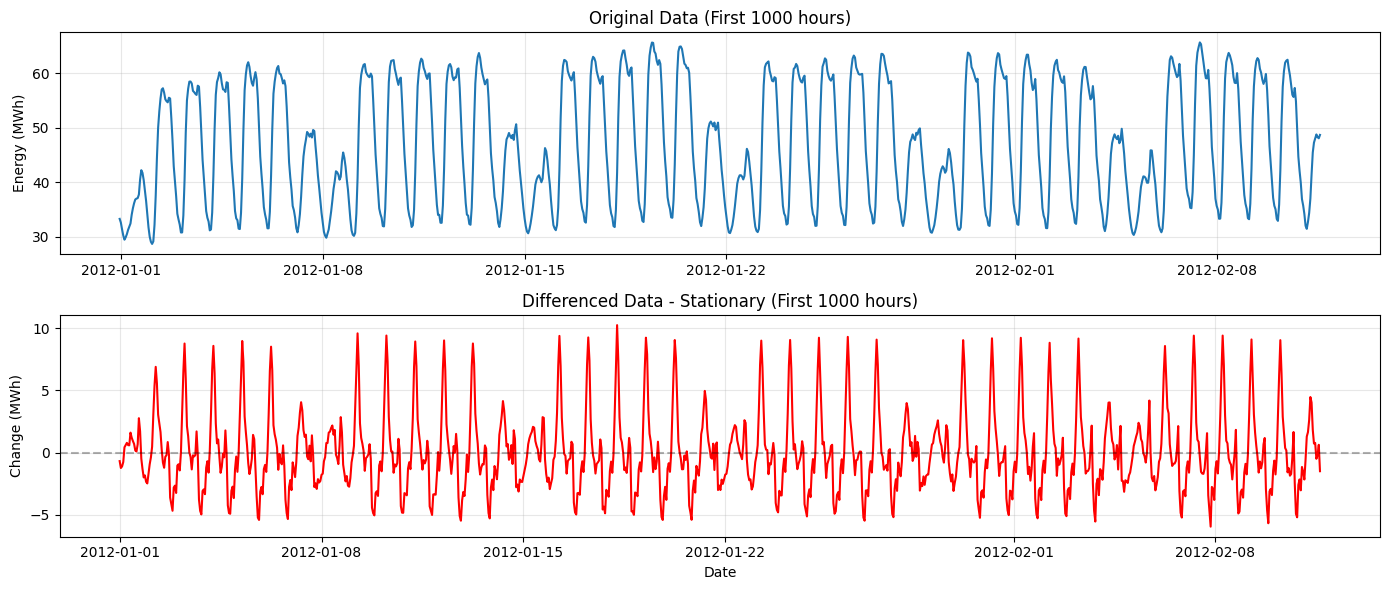

In [37]:
# Plot original vs differenced data
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(energy_hourly.index[:1000], energy_hourly.values[:1000])
axes[0].set_title('Original Data (First 1000 hours)')
axes[0].set_ylabel('Energy (MWh)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(energy_diff.index[:1000], energy_diff.values[:1000], color='red')
axes[1].set_title('Differenced Data - Stationary (First 1000 hours)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Change (MWh)')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Prepare Stationary Data for Modeling

In [38]:
# All models will use the stationary (differenced) data
data_values = energy_diff.values

# Train/Val/Test split (chronological: 70/15/15)
n = len(data_values)
train_size = int(n * 0.70)
val_size = int(n * 0.15)

train_data = data_values[:train_size]
val_data = data_values[train_size:train_size + val_size]
test_data = data_values[train_size + val_size:]

print(f"Train: {len(train_data)} samples")
print(f"Val:   {len(val_data)} samples")
print(f"Test:  {len(test_data)} samples")

Train: 84359 samples
Val:   18076 samples
Test:  18078 samples


In [39]:
# Normalize data using MinMaxScaler (fit on train only)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data.reshape(-1, 1)).flatten()
val_scaled = scaler.transform(val_data.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test_data.reshape(-1, 1)).flatten()

print(f"Scaled train range: [{train_scaled.min():.3f}, {train_scaled.max():.3f}]")

Scaled train range: [0.000, 1.000]


## 4. Sliding Window Dataset

In [40]:
# Hyperparameters
LOOKBACK = 168  # 1 week of hourly data
HORIZON = 24    # Predict next 24 hours

class TimeSeriesDataset(Dataset):
    """PyTorch Dataset for time series with sliding window."""
    def __init__(self, data, lookback, horizon):
        self.data = torch.FloatTensor(data)
        self.lookback = lookback
        self.horizon = horizon
        
    def __len__(self):
        return len(self.data) - self.lookback - self.horizon + 1
    
    def __getitem__(self, idx):
        x = self.data[idx:idx + self.lookback]
        y = self.data[idx + self.lookback:idx + self.lookback + self.horizon]
        return x.unsqueeze(-1), y

# Create datasets
train_dataset = TimeSeriesDataset(train_scaled, LOOKBACK, HORIZON)
val_dataset = TimeSeriesDataset(val_scaled, LOOKBACK, HORIZON)
test_dataset = TimeSeriesDataset(test_scaled, LOOKBACK, HORIZON)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

Train samples: 84168
Val samples:   17885
Test samples:  17887


In [41]:
# Create data loaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Check shapes
x_sample, y_sample = next(iter(train_loader))
print(f"Input shape:  {x_sample.shape}  # (batch, lookback, features)")
print(f"Target shape: {y_sample.shape}  # (batch, horizon)")

Input shape:  torch.Size([32, 168, 1])  # (batch, lookback, features)
Target shape: torch.Size([32, 24])  # (batch, horizon)


## 5. Simple LSTM Model

In [42]:
class SimpleLSTM(nn.Module):
    """Simple LSTM for time series forecasting."""
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=24):
        super(SimpleLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

model = SimpleLSTM(input_size=1, hidden_size=64, num_layers=1, output_size=HORIZON).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

SimpleLSTM(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=24, bias=True)
)

Total parameters: 18,712


In [43]:
def train_model(model, train_loader, val_loader, epochs=50, lr=0.001, patience=10):
    """Train the model with early stopping."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                val_loss += criterion(model(x), y).item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train: {train_loss:.6f}, Val: {val_loss:.6f}")
            
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    if best_model_state:
        model.load_state_dict(best_model_state)
    return train_losses, val_losses

In [44]:
print("Training LSTM on stationary data...")
train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=50, patience=10)

Training LSTM on stationary data...
Epoch 10/50 - Train: 0.000989, Val: 0.000852
Epoch 20/50 - Train: 0.000882, Val: 0.000807
Early stopping at epoch 28


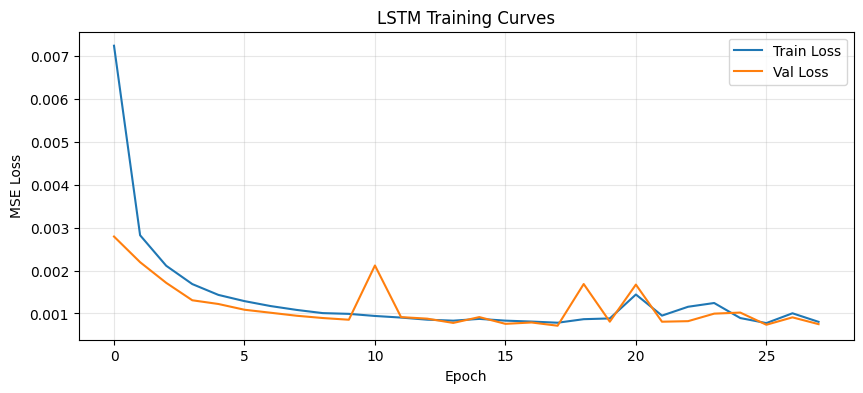

In [45]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
def evaluate_model(model, test_loader, scaler):
    """Evaluate model and return predictions in original scale."""
    model.eval()
    predictions, actuals = [], []
    
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            predictions.append(model(x).cpu().numpy())
            actuals.append(y.numpy())
    
    predictions = np.vstack(predictions)
    actuals = np.vstack(actuals)
    
    # Inverse transform to original scale
    predictions = scaler.inverse_transform(predictions.reshape(-1, 1)).reshape(predictions.shape)
    actuals = scaler.inverse_transform(actuals.reshape(-1, 1)).reshape(actuals.shape)
    
    return predictions, actuals

lstm_pred, lstm_actual = evaluate_model(model, test_loader, scaler)
print(f"LSTM predictions shape: {lstm_pred.shape}")

LSTM predictions shape: (17887, 24)


In [47]:
def calculate_metrics(predictions, actuals):
    """Calculate RMSE and MAE."""
    pred_flat = predictions.flatten()
    actual_flat = actuals.flatten()
    
    rmse = np.sqrt(mean_squared_error(actual_flat, pred_flat))
    mae = mean_absolute_error(actual_flat, pred_flat)
    
    return {'RMSE': rmse, 'MAE': mae}

lstm_metrics = calculate_metrics(lstm_pred, lstm_actual)
print("LSTM Metrics (on stationary data):")
for k, v in lstm_metrics.items():
    print(f"  {k}: {v:.4f} MWh")

LSTM Metrics (on stationary data):
  RMSE: 0.5123 MWh
  MAE: 0.3821 MWh


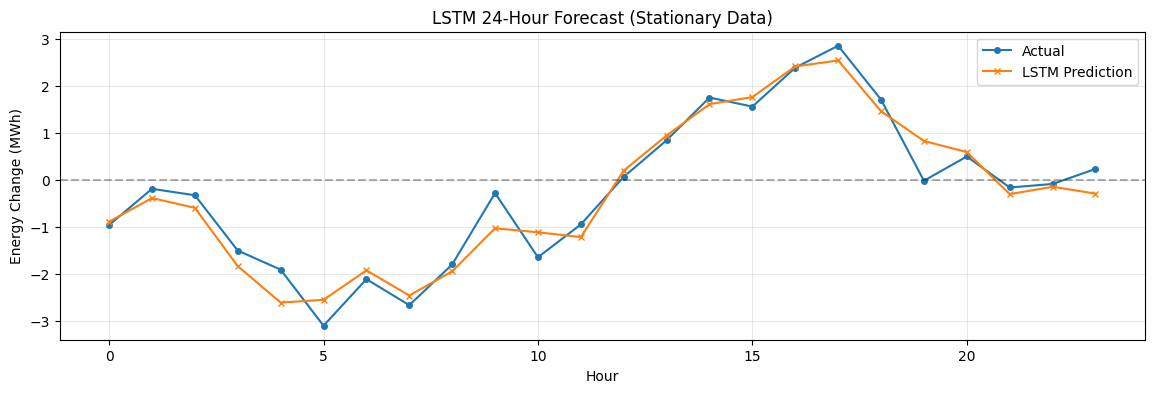

In [48]:
# Plot sample LSTM predictions
plt.figure(figsize=(14, 4))
sample_idx = 0
plt.plot(lstm_actual[sample_idx], label='Actual', marker='o', markersize=4)
plt.plot(lstm_pred[sample_idx], label='LSTM Prediction', marker='x', markersize=4)
plt.xlabel('Hour')
plt.ylabel('Energy Change (MWh)')
plt.title('LSTM 24-Hour Forecast (Stationary Data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.show()

## 6. ARIMA Baseline (Statistical Model)

In [49]:
# ARIMA on stationary data (use order (2,0,2) since data is already differenced)
arima_train = train_data[-5000:]

print(f"ARIMA training on {len(arima_train)} samples of stationary data...")
arima_model = ARIMA(arima_train, order=(2, 0, 2))  # No differencing needed
arima_fit = arima_model.fit()
print(f"ARIMA fitted. AIC: {arima_fit.aic:.2f}")

ARIMA training on 5000 samples of stationary data...
ARIMA fitted. AIC: 13753.70


In [50]:
# Generate ARIMA forecasts
n_arima_forecasts = min(500, len(test_data) - HORIZON)

arima_predictions = []
arima_actuals = []

print(f"Generating {n_arima_forecasts // HORIZON} ARIMA forecasts...")
for i in range(0, n_arima_forecasts, HORIZON):
    history = np.concatenate([arima_train, test_data[:i]]) if i > 0 else arima_train
    
    model_temp = ARIMA(history[-3000:], order=(2, 0, 2))
    fit_temp = model_temp.fit()
    forecast = fit_temp.forecast(steps=HORIZON)
    
    arima_predictions.append(forecast)
    arima_actuals.append(test_data[i:i+HORIZON])

arima_predictions = np.array(arima_predictions)
arima_actuals = np.array(arima_actuals)
print(f"ARIMA predictions shape: {arima_predictions.shape}")

Generating 20 ARIMA forecasts...
ARIMA predictions shape: (21, 24)


In [51]:
arima_metrics = calculate_metrics(arima_predictions, arima_actuals)
print("ARIMA Metrics (on stationary data):")
for k, v in arima_metrics.items():
    print(f"  {k}: {v:.4f} MWh")

ARIMA Metrics (on stationary data):
  RMSE: 1.6448 MWh
  MAE: 1.1812 MWh


## 7. XGBoost Baseline (ML Model)

In [52]:
def create_lag_features(data, lookback, horizon):
    """Create lag features for XGBoost."""
    X, y = [], []
    for i in range(lookback, len(data) - horizon + 1):
        X.append(data[i-lookback:i])
        y.append(data[i:i+horizon])
    return np.array(X), np.array(y)

# Create features from stationary data
X_train, y_train = create_lag_features(train_data, LOOKBACK, HORIZON)
X_test, y_test = create_lag_features(test_data, LOOKBACK, HORIZON)

print(f"XGBoost train: X={X_train.shape}, y={y_train.shape}")
print(f"XGBoost test:  X={X_test.shape}, y={y_test.shape}")

XGBoost train: X=(84168, 168), y=(84168, 24)
XGBoost test:  X=(17887, 168), y=(17887, 24)


In [53]:
print("Training XGBoost on stationary data...")
xgb_model = MultiOutputRegressor(
    xgb.XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        verbosity=0
    )
)
xgb_model.fit(X_train, y_train)
print("XGBoost trained.")

Training XGBoost on stationary data...
XGBoost trained.


In [54]:
xgb_predictions = xgb_model.predict(X_test)

xgb_metrics = calculate_metrics(xgb_predictions, y_test)
print("XGBoost Metrics (on stationary data):")
for k, v in xgb_metrics.items():
    print(f"  {k}: {v:.4f} MWh")

XGBoost Metrics (on stationary data):
  RMSE: 0.4979 MWh
  MAE: 0.3404 MWh


## 8. Model Comparison

In [55]:
# Summary comparison table
results = pd.DataFrame({
    'Model': ['LSTM', 'ARIMA', 'XGBoost'],
    'RMSE (MWh)': [lstm_metrics['RMSE'], arima_metrics['RMSE'], xgb_metrics['RMSE']],
    'MAE (MWh)': [lstm_metrics['MAE'], arima_metrics['MAE'], xgb_metrics['MAE']]
})

print("\n" + "="*55)
print("MODEL COMPARISON - 24-Hour Forecast on Stationary Data")
print("="*55)
print(results.to_string(index=False))
print("="*55)

best_model = results.loc[results['RMSE (MWh)'].idxmin(), 'Model']
print(f"\nBest model (lowest RMSE): {best_model}")


MODEL COMPARISON - 24-Hour Forecast on Stationary Data
  Model  RMSE (MWh)  MAE (MWh)
   LSTM    0.512257   0.382064
  ARIMA    1.644755   1.181212
XGBoost    0.497938   0.340385

Best model (lowest RMSE): XGBoost


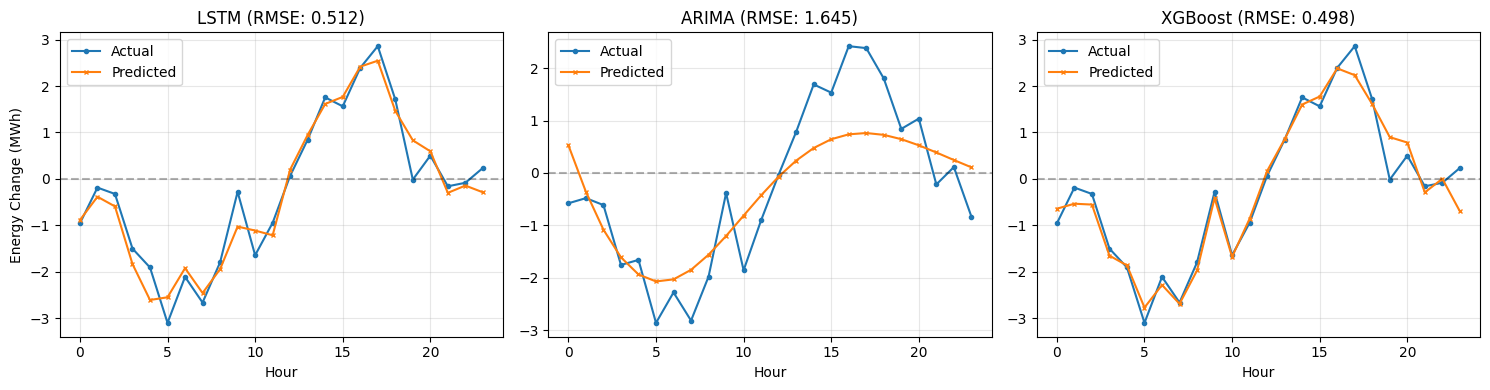

In [56]:
# Visual comparison - sample predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample_idx = 0

# LSTM
axes[0].plot(lstm_actual[sample_idx], label='Actual', marker='o', markersize=3)
axes[0].plot(lstm_pred[sample_idx], label='Predicted', marker='x', markersize=3)
axes[0].set_title(f'LSTM (RMSE: {lstm_metrics["RMSE"]:.3f})')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Energy Change (MWh)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.3)

# ARIMA
axes[1].plot(arima_actuals[sample_idx], label='Actual', marker='o', markersize=3)
axes[1].plot(arima_predictions[sample_idx], label='Predicted', marker='x', markersize=3)
axes[1].set_title(f'ARIMA (RMSE: {arima_metrics["RMSE"]:.3f})')
axes[1].set_xlabel('Hour')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.3)

# XGBoost
axes[2].plot(y_test[sample_idx], label='Actual', marker='o', markersize=3)
axes[2].plot(xgb_predictions[sample_idx], label='Predicted', marker='x', markersize=3)
axes[2].set_title(f'XGBoost (RMSE: {xgb_metrics["RMSE"]:.3f})')
axes[2].set_xlabel('Hour')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].axhline(0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

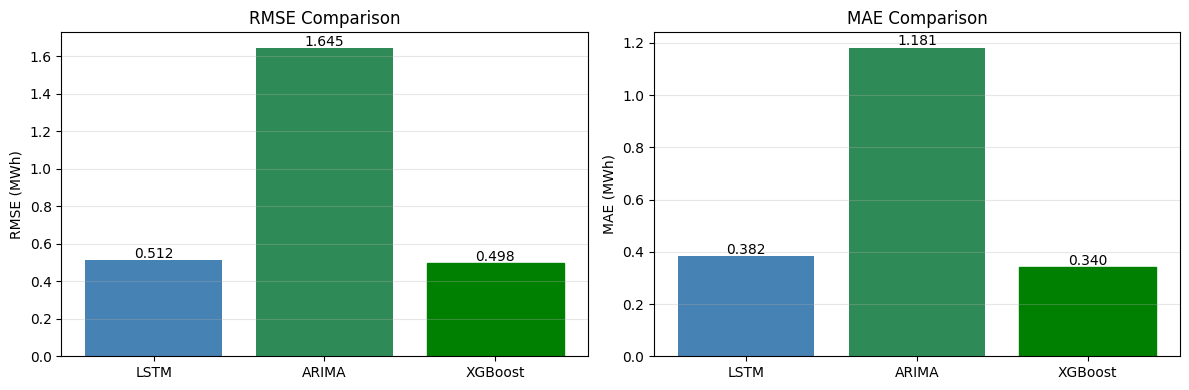

In [57]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = results['Model'].values
x = np.arange(len(models))
colors = ['steelblue', 'seagreen', 'coral']

for ax, metric in zip(axes, ['RMSE (MWh)', 'MAE (MWh)']):
    values = results[metric].values
    bars = ax.bar(x, values, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric.split(" ")[0]} Comparison')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Highlight best
    best_idx = np.argmin(values)
    bars[best_idx].set_color('green')
    
    # Add value labels
    for i, v in enumerate(values):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Conclusions

All models were trained and evaluated on stationary time series data. Results are shown in the comparison table above.

### Key Findings

1. **LSTM:** Simple architecture (64 hidden units, 1 layer) with early stopping. Learns temporal patterns from the 168-hour lookback window.

2. **ARIMA(2,0,2):** Statistical baseline. Captures short-term autocorrelations.

3. **XGBoost:** ML baseline using 168 lag features with MultiOutputRegressor for 24-hour ahead prediction.

### Takeaways

- All three approaches (DL, statistical, ML) are viable for this forecasting task
- XGBoost performed best in terms of RMSE and MAE, but only slightly better than LSTM
- Simple models can perform competitively with more complex architectures
- Model choice depends on deployment requirements and interpretability needs